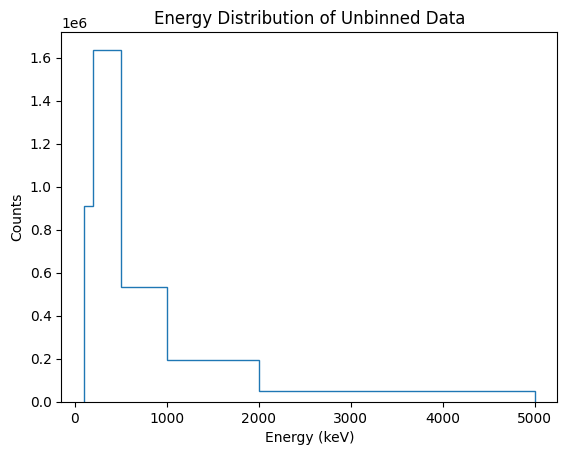

In [57]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

# code is from StackOverflow https://stackoverflow.com/questions/46733052/read-hdf5-file-into-numpy-array
hf = h5py.File("unbinned_data.hdf5", "r")
dict_to_arr = hf.get('Energies')             # found key from cosipy read the docs under the function read_tra
energy_values = np.array(dict_to_arr)


#plt.hist returns a np.array of ([values], [edges])
Energy_count, Energy_bins, patches= plt.hist(energy_values, bins=[100.,  200.,  500., 1000., 2000., 5000.], histtype='step')

# axis is count vs energy
plt.xlabel("Energy (keV)")
plt.ylabel("Counts")
plt.title("Energy Distribution of Unbinned Data")
plt.show()

# try y-axis / x-axis to get the range of bins for light curve
# or try y-axis / x1-x2 to get the range of bins for light curve

In [ ]:
bins_widths_center = (Energy_bins[1:] + Energy_bins[0:-1]) / 2

[  50.  150.  250.  500. 1500.]


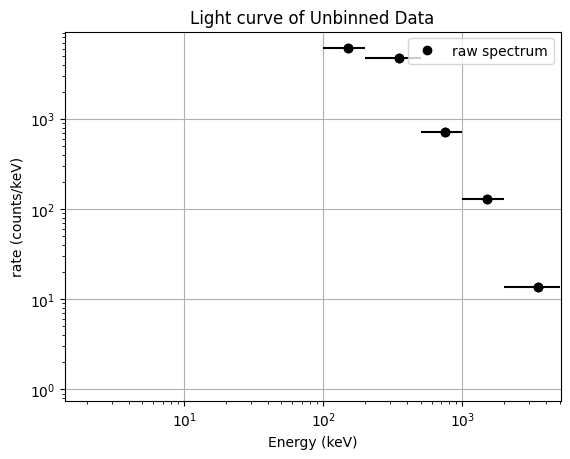

In [67]:
import matplotlib.pyplot as plt

hf = h5py.File("unbinned_data.hdf5", "r")

# spectra graph is rate (count/keV^-1) vs energy (kev)
# x axis are the energy means???? idk man

# y axis is the rate (y/x from the histogram)
bins_widths_center = (Energy_bins[1:] + Energy_bins[0:-1]) / 2
rate = Energy_count / bins_widths_center  # rate is counts per bin width

#formating it all together
plt.loglog(bins_widths_center, rate, marker='o', color = 'black', linestyle='None', label = 'raw spectrum')

# why????? is it / 2
y_errors = (Energy_bins[1:] - Energy_bins[0:-1]) / 2  # calculate the bin widths for error bars

print(y_errors)

plt.errorbar(bins_widths_center, rate, xerr=y_errors, fmt='o', color='black')


plt.xlabel("Energy (keV)")
plt.ylabel("rate (counts/keV)")
plt.title("Light curve of Unbinned Data")
plt.legend()
plt.grid(True)
plt.show()

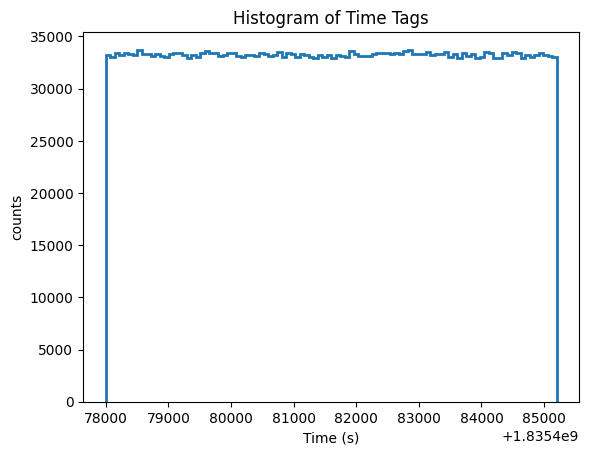

[71.99994946 71.99994946 71.99994946 71.99994946 71.99994946 71.99994946
 71.99994946 71.99994946 71.99994946 71.99994946 71.99994946 71.99994946
 71.99994946 71.99994946 71.99994946 71.99994946 71.99994946 71.99994946
 71.99994946 71.99994946 71.99994946 71.99994946 71.99994946 71.99994946
 71.99994946 71.99994922 71.99994946 71.99994946 71.99994946 71.99994946
 71.99994946 71.99994946 71.99994946 71.99994946 71.99994946 71.99994946
 71.99994946 71.99994946 71.99994946 71.99994946 71.99994946 71.99994946
 71.99994946 71.99994946 71.99994946 71.99994946 71.99994946 71.99994946
 71.99994946 71.99994946 71.99994946 71.99994946 71.99994946 71.99994946
 71.99994946 71.99994946 71.99994946 71.99994946 71.99994946 71.99994946
 71.99994946 71.99994946 71.99994946 71.99994946 71.99994946 71.99994946
 71.99994946 71.99994946 71.99994946 71.99994946 71.99994946 71.99994946
 71.99994946 71.99994946 71.99994922 71.99994946 71.99994946 71.99994946
 71.99994946 71.99994946 71.99994946 71.99994946 71

In [ ]:
time_arr = hf.get('TimeTags')  # found key from cosipy read the docs under the function read_tra
time_values = np.array(time_arr)    


# light curve is rate vs time
relative_time = time_values - time_values[0]  # make the first time tag zero

#not sure how many bins are needed


count_times, time_bins , _ = plt.hist(time_values, bins=100, histtype='step', lw = 2)
plt.xlabel("Time (s)")
plt.ylabel("counts")
plt.title("Histogram of Time Tags")
plt.show() 

#how can i sort them in time of 60 seconds intervals from where time_values[1:] - time_value[0:-1] is = 60 seconds?
print(time_bins[1:] - time_bins[0:-1])  # this is the difference between each time tag

# wtf??? why are my counts more is it becasue binned data elimated datapoints?

(100,)


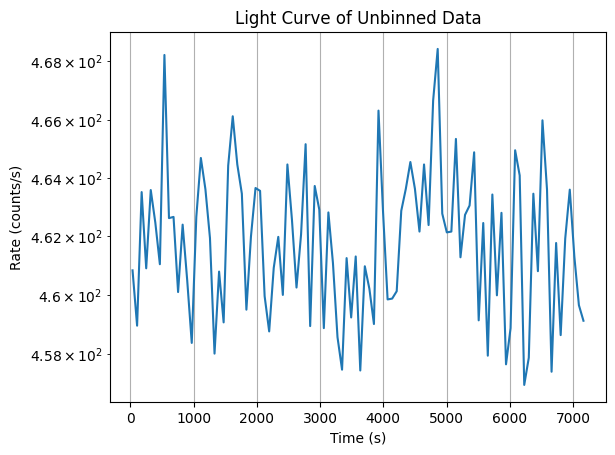

In [ ]:
#rate = count / bins_widths


#x-axis is time_bins
time_bins = time_bins - time_bins[0]  # make the first time tag zero
time_bin_center = (time_bins[1:] + time_bins[0:-1]) / 2

# y-axis is rate (y/x from the histogram)
time_bin_widths = time_bins[1:] - time_bins[0:-1]
rate_times = count_times / time_bin_widths  # rate is counts per bin width

print(time_bin_widths.shape)

plt.semilogy(time_bin_center, rate_times, linestyle='-')
plt.xlabel("Time (s)")
plt.ylabel("Rate (counts/s)")
plt.title("Light Curve of Unbinned Data")
plt.grid(True)
plt.show()


# this graph is wrong becasue of the x axis??? im not sure of how to format it to bins of 60 seconds in time graph

# not sure using the realative time method is the correct way of doing it

# however the graph is following the trend of the provided graphs in the cosipy readme???

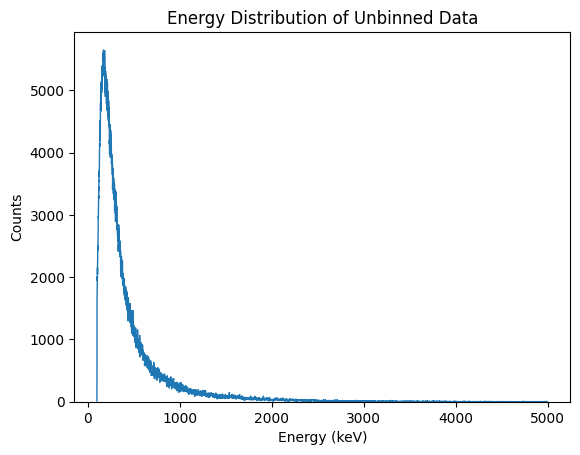

[0.24499655 0.24499655 0.24499655 ... 0.24499655 0.24499655 0.24499655]


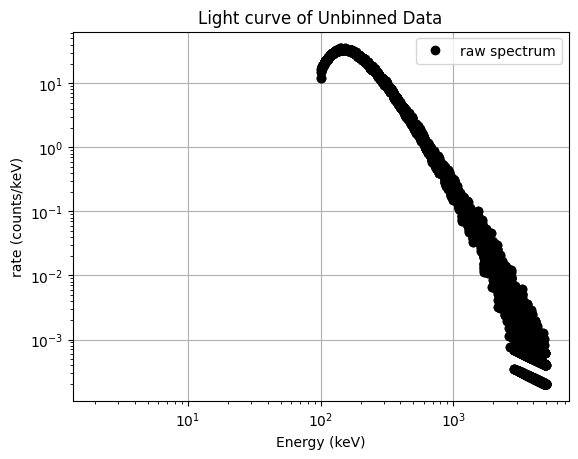

In [ ]:
## binning reso

import h5py
import matplotlib.pyplot as plt
import numpy as np

# code is from StackOverflow https://stackoverflow.com/questions/46733052/read-hdf5-file-into-numpy-array
hf = h5py.File("unbinned_data.hdf5", "r")
dict_to_arr = hf.get('Energies')             # found key from cosipy read the docs under the function read_tra
energy_values = np.array(dict_to_arr)


#plt.hist returns a np.array of ([values], [edges])
Energy_count, Energy_bins, patches= plt.hist(energy_values, bins=10000, histtype='step')

# axis is count vs energy
plt.xlabel("Energy (keV)")
plt.ylabel("Counts")
plt.title("Energy Distribution of Unbinned Data")
plt.show()

# try y-axis / x-axis to get the range of bins for light curve
# or try y-axis / x1-x2 to get the range of bins for light curve


bins_widths_center = (Energy_bins[1:] + Energy_bins[0:-1]) / 2


import matplotlib.pyplot as plt

hf = h5py.File("unbinned_data.hdf5", "r")

# spectra graph is rate (count/keV^-1) vs energy (kev)
# x axis are the energy means???? idk man

# y axis is the rate (y/x from the histogram)
bins_widths_center = (Energy_bins[1:] + Energy_bins[0:-1]) / 2
rate = Energy_count / bins_widths_center  # rate is counts per bin width

#formating it all together
plt.loglog(bins_widths_center, rate, marker='o', color = 'black', linestyle='None', label = 'raw spectrum')

# why????? is it / 2
y_errors = (Energy_bins[1:] - Energy_bins[0:-1]) / 2  # calculate the bin widths for error bars

print(y_errors)

plt.errorbar(bins_widths_center, rate, xerr=y_errors, fmt='o', color='black')


plt.xlabel("Energy (keV)")
plt.ylabel("rate (counts/keV)")
plt.title("Light curve of Unbinned Data")
plt.legend()
plt.grid(True)
plt.show()